# 注意力机制 Attention：从零手写实现

> 不调用任何现成注意力模块，只用 PyTorch 最基础的张量运算，一步一步拆解 Attention 的每个部件——从单个向量的点积，到完整的多头注意力与 Transformer Block，最后用两个 Demo 看到"注意力"究竟在看什么。

**实现约定**：全程**不使用** `nn.MultiheadAttention`、`nn.Transformer*`、`F.scaled_dot_product_attention` 等现成模块；只允许 `torch` 基础张量运算、`nn.Parameter` 与 `nn.Module` 的参数管理外壳（`nn.Linear` 也手写替代）。第 8 节会反过来调用官方实现做**数值对照**，验证我们手写的正确性。

**目录**

1. 引子：为什么需要注意力
2. 核心思想：Query / Key / Value 与缩放点积公式
3. 最小可运行例子：一个查询的注意力，逐步拆解
4. 矩阵形式：整句一次算完，以及 $\sqrt{d_k}$ 缩放的数学原理
5. 可学习的自注意力：从零实现 `SelfAttention`
6. 多头注意力：从零实现 `MultiHeadAttention`
7. 因果掩码：让 Decoder"看不到未来"
8. 组装 Transformer Block，并与官方实现数值对照验证
9. Demo 1：看见注意力——权重热力图
10. Demo 2：训练微型 Transformer 学"序列反转"
11. 总结与思考题

## 1. 引子：为什么需要注意力

在 Attention 出现之前，序列建模的主力是**循环神经网络（RNN）**。把一句话 $x_1, x_2, \dots, x_n$ 喂给 RNN，它必须**从左到右一个词一个词地读**，把历史信息不断压缩进一个隐状态 $h_t$：

$$h_t = f(h_{t-1}, x_t)$$

这个结构有两个致命弱点：

| 问题 | 原因 | 后果 |
| --- | --- | --- |
| **串行计算** | $h_t$ 依赖 $h_{t-1}$，无法并行 | 训练慢，序列越长越痛苦 |
| **长程依赖衰减** | 第 1 个词的信息要经过 $t-1$ 次传递才能影响第 $t$ 步 | 距离一远，信息被稀释、梯度消失，"开头说了什么"早就忘了 |

CNN 也有类似问题：卷积核一次只看局部窗口，想看到远处的词就得堆很多层，感受野才慢慢扩大。

### 1.1 注意力的一句话思想

> **不要把信息压缩成一条流水线上的隐状态，而是让每个位置都能"一步直达"序列中的任何其他位置，并按"相关程度"决定看多少。**

- **并行**：任何两个位置之间的信息路径长度都是 $O(1)$（RNN 是 $O(n)$），且所有位置可以同时计算；
- **按需分配**：相关的内容多看一点，无关的内容少看甚至不看——权重是**动态计算**出来的，取决于当前内容和候选内容的匹配程度，而不是像卷积权重那样固定。

### 1.2 一个生活类比

想象你在图书馆写论文，手头有一个**问题**（"Transformer 的作者是谁？"）：

1. 你带着这个问题去**检索**书架上每本书的**书脊标签**（主题、作者、标题）；
2. 每本书的标签和你的问题**比对相似度**——讲 Transformer 的书匹配度高，讲烹饪的书匹配度低；
3. 相似度归一化成一组**权重**（加起来等于 1）；
4. 按权重**翻阅并摘抄每本书的内容**，加权汇总成一段笔记。

这四步就是注意力机制的全部：**带着查询 → 和键比对 → 得到权重 → 加权取值**。下一节我们把它翻译成数学。

2017 年，Google 的论文《Attention Is All You Need》正是基于这个机制搭出了 Transformer——去掉了 RNN，只留注意力，成了如今几乎所有大语言模型（GPT、BERT、LLaMA……）的基石。今天我们就把它的核心部件亲手写一遍。

## 2. 核心思想：Query / Key / Value 与缩放点积公式

### 2.1 三个角色

注意力给序列中**每一个 token 的向量**安排了三种"化身"，它们都由同一个原始向量乘以不同的矩阵（投影）得到：

| 角色 | 符号 | 图书馆类比 | 作用 |
| --- | --- | --- | --- |
| **查询 Query** | $q$ | 你心中的问题："我想找什么？" | 代表当前 token **主动发出**的信息需求 |
| **键 Key** | $k$ | 书脊上的标签："我这里有什么" | 用来被检索、打分的**索引** |
| **值 Value** | $v$ | 书里真正的内容："我的实际信息" | 匹配成功后真正被取走的内容 |

**为什么 Key 和 Value 要分开？** 因为"用来匹配的特征"和"值得传递的内容"未必是同一回事。书的标签是精心提炼的摘要，而正文信息量大得多；同理，token 的"可检索特征"与"要输出的信息"由不同矩阵投影，让模型各自学习。

### 2.2 缩放点积注意力（Scaled Dot-Product Attention）

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

对照图书馆四步：

| 公式部件 | 含义 | 图书馆类比 |
| --- | --- | --- |
| $QK^{\top}$ | 所有查询与所有键的**点积**——相似度打分 | 问题 vs 每个书脊标签的匹配度 |
| $\div \sqrt{d_k}$ | **缩放**，防止分数过大（4.4 节详述） | 把打分标准化，避免"一家独大" |
| $\mathrm{softmax}(\cdot)$ | 把分数归一化成**总和为 1 的权重** | "这本书占我注意力的百分之几" |
| $\cdot V$ | 按权重**加权求和**所有值向量 | 按比例摘抄每本书的内容 |

### 2.3 形状流转（先记住，后面代码反复出现）

设查询有 $n$ 个、键/值有 $m$ 个、键维度为 $d_k$、值维度为 $d_v$：

$$
\underbrace{Q}_{(n,\,d_k)} \times
\underbrace{K^{\top}}_{(d_k,\,m)} \to
\underbrace{S}_{(n,\,m)} \xrightarrow{\text{softmax 按行}}
\underbrace{A}_{(n,\,m)} \times
\underbrace{V}_{(m,\,d_v)} \to
\underbrace{O}_{(n,\,d_v)}
$$

- 分数矩阵 $S$ 的第 $(i,j)$ 元 = 第 $i$ 个查询与第 $j$ 个键的相似度；
- 权重矩阵 $A$ 的每一行是一个 softmax 分布：第 $i$ 个查询把注意力分配给 $m$ 个候选的比例；
- 输出 $O$ 的每一行 = 对应查询"消化"完整个序列后的新表示。

**自注意力（self-attention）**：$Q, K, V$ 都来自**同一个序列**——每个词既是提问者，也是候选者。这样每个词都能吸收全句上下文，这正是 Transformer 编码器的做法。下一节用最小数值例子把这条流水线跑一遍。

## 3. 最小可运行例子：一个查询的注意力，逐步拆解

为了让每一步都"看得见"，我们**不用任何可学习参数**，直接手工设计向量：

- 维度只有 $d_k = d_v = 4$，且每个维度的语义都是明示的：`[是动物, 是食物, 是交通工具, 体型大小]`；
- 库里有 4 个候选 token：**猫、狗、汽车、披萨**；
- 查询 $q$ 代表"强烈想找动物，体型中等偏上"→ `[2, 0, 0, 1]`（"非动物"的候选在动物维上是负分，会被明确排斥）。

接下来把公式 $\mathrm{softmax}(qK^{\top}/\sqrt{d_k})V$ 拆成 4 步，每一步打印中间结果。

In [4]:
import torch

torch.manual_seed(0)

# ---------- 手工设计的数据 ----------
names = ['猫', '狗', '汽车', '披萨']                     # 候选 token（仅用于打印）
#          维度语义:    [是动物, 是食物, 是交通工具, 体型大小]
K = torch.tensor([[ 1.8,  0.0,  0.0, 0.4],            # 猫的键：强动物、小体型
                  [ 1.6,  0.0,  0.0, 1.2],            # 狗的键：强动物、中等体型
                  [-0.6,  0.0,  1.8, 1.6],            # 汽车的键：非动物（负分）、强交通工具
                  [-0.6,  1.8,  0.0, 0.6]])           # 披萨的键：非动物（负分）、强食物
V = torch.tensor([[1.0, 0.0, 0.0],                    # 猫的值（内容）：会抓老鼠
                  [0.8, 0.2, 0.0],                    # 狗的值：会看家、会捡球
                  [0.0, 0.0, 1.0],                    # 汽车的值：能载人
                  [0.0, 1.0, 0.0]])                   # 披萨的值：好吃
q = torch.tensor([2.0, 0.0, 0.0, 1.0])                # 查询："强烈要动物，体型中等偏上"

print('K 形状 (m, d_k) =', tuple(K.shape))   # 4 个候选，键维度 4
print('V 形状 (m, d_v) =', tuple(V.shape))   # 4 个候选，值维度 3
print('q 形状 (d_k,)   =', tuple(q.shape))

K 形状 (m, d_k) = (4, 4)
V 形状 (m, d_v) = (4, 3)
q 形状 (d_k,)   = (4,)


### Step 1：点积打分 $qK^{\top}$

点积 $\langle q, k_j\rangle = \sum_i q_i k_{j,i}$ 衡量两个向量的**对齐程度**：方向越一致分数越高。直觉上就是"查询里的每个语义维度，去键里找同样的语义维度"——查询说"要动物"，猫、狗的键在"动物"维上数值大，于是得高分；汽车、披萨在"动物"维上是 0，得分被压低。

In [5]:
scores = K @ q                    # 等价于对每个 k_j 算点积 <q, k_j>
print('scores 形状 (m,) =', tuple(scores.shape))
for name, s in zip(names, scores):
    print(f'  与「{name}」的原始分数 = {s:.3f}')

scores 形状 (m,) = (4,)
  与「猫」的原始分数 = 4.000
  与「狗」的原始分数 = 4.400
  与「汽车」的原始分数 = 0.400
  与「披萨」的原始分数 = -0.600


### Step 2：缩放 $\div\sqrt{d_k}$

原始分数除以 $\sqrt{d_k}=\sqrt{4}=2$。本例维度太小看不出威力，但请记住它的目的：**维度越大，点积的方差越大**，大分数会把 softmax 推向"one-hot"，导致梯度消失。数学原因在 4.4 节用实验验证。

In [6]:
import math

d_k = K.shape[-1]                 # 键的维度
scaled = scores / math.sqrt(d_k)  # 缩放
print(f'√d_k = {math.sqrt(d_k)}')
for name, s0, s1 in zip(names, scores, scaled):
    print(f'  「{name}」: {s0:.3f}  -->  {s1:.3f}')

√d_k = 2.0
  「猫」: 4.000  -->  2.000
  「狗」: 4.400  -->  2.200
  「汽车」: 0.400  -->  0.200
  「披萨」: -0.600  -->  -0.300


### Step 3：softmax 归一化 → 注意力权重

softmax 把任意实数分数变成**总和为 1 的正数分布**，且保序、放大差距：

$$\mathrm{softmax}(z)_j = \frac{e^{z_j}}{\sum_i e^{z_i}}$$

得到的第 $j$ 个权重就是"第 $j$ 个候选占用的注意力比例"。我们先**手写一遍 softmax**，再用 `torch.softmax` 对照，确认一致。

In [7]:
def my_softmax(z):
    # 减去最大值做数值稳定（防 e^z 溢出），这不改变 softmax 结果
    z = z - z.max()
    e = torch.exp(z)
    return e / e.sum()

weights = my_softmax(scaled)
weights_ref = torch.softmax(scaled, dim=-1)      # 官方实现对照

print('注意力权重：')
for name, w in zip(names, weights):
    print(f'  「{name}」: {w:.4f}')
print(f'权重总和 = {weights.sum():.4f}')
print('与 torch.softmax 最大偏差 =', (weights - weights_ref).abs().max().item())

注意力权重：
  「猫」: 0.4021
  「狗」: 0.4911
  「汽车」: 0.0665
  「披萨」: 0.0403
权重总和 = 1.0000
与 torch.softmax 最大偏差 = 3.725290298461914e-09


### Step 4：加权求和 $\sum_j \alpha_j v_j$

用权重把所有值向量按比例混合，得到最终输出——这就是该查询"读懂"整个库之后形成的**新表示**：

$$\mathrm{output} = \sum_{j=1}^{m} \alpha_j\, v_j$$

注意输出是所有 $v_j$ 的**凸组合**（权重非负、和为 1），因此输出向量一定落在这些值向量张成的"混合体"之内。猫、狗权重高，所以输出里"会抓老鼠"和"会看家"的成分就浓；"能载人""好吃"几乎被抹掉。

In [8]:
output = weights @ V              # (m,) @ (m, d_v) -> (d_v,)
print('output 形状 (d_v,) =', tuple(output.shape))
print('output =', output)

print('\n加权分解（每个候选贡献了多少）：')
for name, w, v in zip(names, weights, V):
    print(f'  {w:.3f} × {list(v.tolist())}  ←「{name}」')

# 验证：输出确实是权重与 V 的加权平均
manual = sum(w * v for w, v in zip(weights, V))
print('\n与逐项加权的最大偏差 =', (output - manual).abs().max().item())

output 形状 (d_v,) = (3,)
output = tensor([0.7950, 0.1385, 0.0665])

加权分解（每个候选贡献了多少）：
  0.402 × [1.0, 0.0, 0.0]  ←「猫」
  0.491 × [0.800000011920929, 0.20000000298023224, 0.0]  ←「狗」
  0.066 × [0.0, 0.0, 1.0]  ←「汽车」
  0.040 × [0.0, 1.0, 0.0]  ←「披萨」

与逐项加权的最大偏差 = 0.0


## 4. 矩阵形式：整批查询一次算完，以及 $\sqrt{d_k}$ 缩放的数学原理

### 4.1 从"一个查询"到"一排查询"

第 3 节只让 1 个查询提问。实际中序列里**每个 token 都是查询**：$n$ 个查询堆成矩阵 $Q\,(n, d_k)$，一次矩阵乘法就能算出所有查询对所有键的分数，再用 `softmax(dim=-1)` **按行**归一化（每行是一个查询自己的注意力分布）。

下面用随机张量走一遍完整流水线，盯住每一步的形状。

In [9]:
import torch

torch.manual_seed(0)

n, m, d_k, d_v = 6, 5, 8, 4   # 6 个查询、5 个候选、键维度 8、值维度 4

Q = torch.randn(n, d_k)       # 查询矩阵：每个 token 一行
K = torch.randn(m, d_k)       # 键矩阵
V = torch.randn(m, d_v)       # 值矩阵

# Step 1: 分数矩阵 (n, d_k) @ (d_k, m) -> (n, m)
scores = Q @ K.T                          # Q @ K.transpose(-2, -1) 的二维写法
print('scores 形状:', tuple(scores.shape), '  scores[i,j] = 第 i 个查询对第 j 个键的分数')

# Step 2: 缩放
scaled = scores / d_k ** 0.5

# Step 3: 按最后一维（每一行）做 softmax -> 每行和为 1
attn_weights = torch.softmax(scaled, dim=-1)
print('\n每行的权重和（都应为 1）:', attn_weights.sum(dim=-1))
print('\n注意力权重矩阵 (n, m)：')
print(attn_weights.round(decimals=3))

# Step 4: 加权求和 (n, m) @ (m, d_v) -> (n, d_v)
output = attn_weights @ V
print('\noutput 形状:', tuple(output.shape), '  output[i] = 第 i 个查询的新表示')

scores 形状: (6, 5)   scores[i,j] = 第 i 个查询对第 j 个键的分数

每行的权重和（都应为 1）: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

注意力权重矩阵 (n, m)：
tensor([[0.1530, 0.0460, 0.1110, 0.5620, 0.1270],
        [0.1070, 0.1930, 0.2630, 0.3330, 0.1040],
        [0.0510, 0.1260, 0.0180, 0.0810, 0.7230],
        [0.0870, 0.0600, 0.1540, 0.6610, 0.0380],
        [0.1820, 0.2180, 0.1600, 0.1980, 0.2420],
        [0.0660, 0.0140, 0.6710, 0.2310, 0.0180]])

output 形状: (6, 4)   output[i] = 第 i 个查询的新表示


### 4.2 为什么是 $\sqrt{d_k}$？——点积的方差分析

**设定**：$q, k \in \mathbb{R}^{d_k}$，各分量独立、均值 0、方差 1。点积 $z = q\cdot k = \sum_{i=1}^{d_k} q_i k_i$ 的统计性质：

$$\mathbb{E}[z] = \sum_i \mathbb{E}[q_i]\,\mathbb{E}[k_i] = 0, \qquad \mathrm{Var}(z) = \sum_i \mathbb{E}[q_i^2]\,\mathbb{E}[k_i^2] = d_k$$

（乘积项 $q_i k_i$ 彼此独立，方差可加；每个乘积项方差为 $1\times 1=1$。）

**结论**：点积的标准差 $\propto \sqrt{d_k}$。维度 $d_k = 512$ 时，分数的典型幅度约 $\pm 22$——softmax 面对这么大的分数会变得**极度尖锐**，几乎 one-hot：

- 输出退化成"只抄一本最像的书"，丢失了混合上下文的能力；
- 更致命的是**梯度消失**：one-hot 处 softmax 的梯度 $\approx 0$，注意力"learn 不动"。

除以 $\sqrt{d_k}$ 恰好把分数方差拉回 $1$，让 softmax 始终工作在"梯度健康"的区间。下面两个实验分别验证方差公式和 softmax 锐度。

In [10]:
# 实验 1：验证 Var(q·k) = d_k
import torch

for d in [4, 64, 512, 2048]:
    q = torch.randn(100_000, d)
    k = torch.randn(100_000, d)
    dots = (q * k).sum(dim=-1)
    print(f'd_k = {d:5d}: 点积标准差 = {dots.std():.3f}（理论 √d_k = {d ** 0.5:.3f}），'
          f'除以√d_k后 = {dots.std() / d ** 0.5:.3f}')

d_k =     4: 点积标准差 = 2.000（理论 √d_k = 2.000），除以√d_k后 = 1.000
d_k =    64: 点积标准差 = 8.013（理论 √d_k = 8.000），除以√d_k后 = 1.002
d_k =   512: 点积标准差 = 22.672（理论 √d_k = 22.627），除以√d_k后 = 1.002
d_k =  2048: 点积标准差 = 45.401（理论 √d_k = 45.255），除以√d_k后 = 1.003


### 4.3 实验 2：缩放与否对 softmax 锐度的影响

固定 $d_k = 512$，构造一批随机的查询-键分数，分别做 softmax（不缩放 / 缩放），统计每行**最大注意力权重**的平均值：

- 接近 1 → one-hot，注意力全押在一个候选上；
- 接近 $1/m$ → 均匀分布，注意力平均撒开。

In [11]:
import torch

d_k, n, m = 512, 200, 100        # 200 个查询、100 个候选
Q = torch.randn(n, d_k)
K = torch.randn(m, d_k)

scores = Q @ K.T                                  # (n, m)
w_no_scale = torch.softmax(scores, dim=-1)        # 不缩放
w_scaled = torch.softmax(scores / d_k ** 0.5, dim=-1)   # 缩放

print(f'不缩放：每行最大权重均值 = {w_no_scale.max(dim=-1).values.mean():.4f}'
      f'（均匀分布应为 {1 / m:.4f}，one-hot 应为 1）')
print(f'缩  放：每行最大权重均值 = {w_scaled.max(dim=-1).values.mean():.4f}')

# 熵：衡量分布的"均匀程度"，one-hot 的熵为 0，均匀分布的熵为 ln(m)
import math
H_no = -(w_no_scale * w_no_scale.clamp_min(1e-12).log()).sum(-1).mean()
H_sc = -(w_scaled * w_scaled.clamp_min(1e-12).log()).sum(-1).mean()
print(f'不缩放：平均熵 = {H_no:.3f}（均匀分布的熵 = {math.log(m):.2f}）')
print(f'缩  放：平均熵 = {H_sc:.3f}')

不缩放：每行最大权重均值 = 0.9305（均匀分布应为 0.0100，one-hot 应为 1）
缩  放：每行最大权重均值 = 0.0814
不缩放：平均熵 = 0.174（均匀分布的熵 = 4.61）
缩  放：平均熵 = 4.120


## 5. 可学习的自注意力：从零实现 `SelfAttention`

### 5.1 从"随机 Q、K、V"到"学出来的 Q、K、V"

前两节的 $Q, K, V$ 是凭空给定的随机矩阵——那注意力没有任何"个性"。真正的自注意力中，三者都由**同一个输入序列** $X\,(n, d_{model})$ 经过**三组可学习的投影**生成：

$$Q = XW_q,\qquad K = XW_k,\qquad V = XW_v$$

- $W_q$ 决定每个 token "**会问什么问题**"；
- $W_k$ 决定每个 token "**用什么特征被检索**"；
- $W_v$ 决定每个 token "**被选中后提供什么内容**"。

这三个矩阵就是注意力要学习的全部核心参数——梯度下降会自动调整它们，让"问答匹配"越来越有利于完成下游任务。这正是 2.1 节"Key 和 Value 分开"的意义：投影让"检索特征"与"传递内容"解耦。

### 5.2 `nn.Parameter`：把矩阵登记成可学习参数

`nn.Parameter(tensor)` 会把张量包装成模块的**可训练参数**：放进 `nn.Module` 后，`model.parameters()` 能收集到它，`loss.backward()` 会自动为它算梯度，优化器能更新它。我们连 `nn.Linear` 都不用（它无非就是 `y = xW + b` 的封装），直接手写这个乘加，看清楚线性层的本质。

初始化时乘一个很小的系数（如 `0.02`，GPT 的做法）：初始投影矩阵不能太大，否则初始分数过大、softmax 一开始就尖锐化，训练起步困难。

In [12]:
import torch
import torch.nn as nn

class SelfAttention(nn.Module):
    '''缩放点积自注意力（无掩码版），支持任意批次维度。
    输入  X: (B, n, d_model)   B 为批量大小，n 为序列长度
    输出 (out, attn):
        out  : (B, n, d_v)  每个位置融合了全序列信息的新表示
        attn : (B, n, n)    注意力权重，attn[b, i, j] = 第 b 个样本中
                            位置 i 对位置 j 的注意力（每行和为 1）
    '''

    def __init__(self, d_model: int, d_k: int, d_v: int):
        super().__init__()
        self.d_k = d_k
        # 三组投影：手写 nn.Linear 的内部实现 y = x @ W + b
        self.W_q = nn.Parameter(torch.randn(d_model, d_k) * 0.02)
        self.b_q = nn.Parameter(torch.zeros(d_k))
        self.W_k = nn.Parameter(torch.randn(d_model, d_k) * 0.02)
        self.b_k = nn.Parameter(torch.zeros(d_k))
        self.W_v = nn.Parameter(torch.randn(d_model, d_v) * 0.02)
        self.b_v = nn.Parameter(torch.zeros(d_v))

    def forward(self, X: torch.Tensor):
        B, n, _ = X.shape

        # ① 投影：同一个 X 换三种"化身"
        Q = X @ self.W_q + self.b_q        # (B, n, d_model) @ (d_model, d_k) -> (B, n, d_k)
        K = X @ self.W_k + self.b_k        # -> (B, n, d_k)
        V = X @ self.W_v + self.b_v        # -> (B, n, d_v)

        # ② 打分：Q 与每个 K 的点积。(B, n, d_k) @ (B, d_k, n) -> (B, n, n)
        scores = Q @ K.transpose(-2, -1)

        # ③ 缩放：除以 √d_k，方差归一（4.2 节）
        scores = scores / self.d_k ** 0.5

        # ④ 归一化：每个查询行独立 softmax，得到注意力分布
        attn = torch.softmax(scores, dim=-1)   # (B, n, n)

        # ⑤ 加权求和：每个位置按权重混合所有值向量
        out = attn @ V                     # (B, n, n) @ (B, n, d_v) -> (B, n, d_v)
        return out, attn

### 5.3 逐行拆解 `forward`

| 行 | 代码 | 形状变化 | 在做什么 |
| --- | --- | --- | --- |
| ① | `Q = X @ W_q + b_q` | $(B,n,d_m)\to(B,n,d_k)$ | 每个词生成"问题" |
| ① | `K = X @ W_k + b_k` | 同上，$d_k$ 维 | 每个词生成"标签" |
| ① | `V = X @ W_v + b_v` | $(B,n,d_v)$ | 每个词生成"内容" |
| ② | `Q @ K.transpose(-2,-1)` | $(B,n,d_k)\to(B,n,n)$ | 所有问题 × 所有标签 = 分数矩阵 |
| ③ | `/ d_k**0.5` | 形状不变 | 方差归一，防 softmax 饱和 |
| ④ | `softmax(dim=-1)` | 形状不变 | 每行变成和为 1 的分布 |
| ⑤ | `attn @ V` | $(B,n,n)\to(B,n,d_v)$ | 按权重混合值向量 |

两个关键细节：

- **`transpose(-2, -1)`**：交换最后两个维度，把 $K$ 变成 $(B, d_k, n)$，这样 `Q @ K^T` 靠广播一次算完整个 batch 的"所有查询 × 所有键"；
- **`dim=-1`**：softmax 沿**最后一维**（每个查询对应的 $n$ 个候选分数）归一化——记住这是新手最常犯的错（错用 `dim=0` 会把不同查询混在一起归一化）。

batch 维 $B$ 从头到尾没有被显式触碰：`@` 和 `softmax(dim=-1)` 都只作用在最后两维上，天然支持批量并行。

In [13]:
# ---------- 实例化并跑一次前向 ----------
torch.manual_seed(0)

d_model, d_k, d_v = 16, 8, 8
attn_module = SelfAttention(d_model, d_k, d_v)

B, n = 2, 5                          # 2 个样本，每个 5 个 token
X = torch.randn(B, n, d_model)
out, attn = attn_module(X)

print(f'输入  X    : {tuple(X.shape)}')
print(f'输出  out  : {tuple(out.shape)}   attn: {tuple(attn.shape)}')

# 性质检查 1：每个查询行的注意力权重和为 1
print('\n每行权重和（应为 1）:', attn.sum(dim=-1)[0].round(decimals=4))

# 性质检查 2：未训练的随机注意力接近均匀分布（1/n = 0.2）
print('\n样本 0 的注意力权重矩阵（初始随机参数，接近均匀）：')
print(attn[0].round(decimals=3).detach())

# 参数量统计：三组投影 = 3 × (d_model×d_out + d_out)
total = sum(p.numel() for p in attn_module.parameters())
print(f'\n可学习参数总数 = {total}（W_q,b_q + W_k,b_k + W_v,b_v）')

# 能否训练：让 loss 对参数求梯度
loss = out.square().mean()
loss.backward()
print('W_q 的梯度形状:', tuple(attn_module.W_q.grad.shape), '→ 参数可正常求导')

输入  X    : (2, 5, 16)
输出  out  : (2, 5, 8)   attn: (2, 5, 5)

每行权重和（应为 1）: tensor([1., 1., 1., 1., 1.], grad_fn=<RoundBackward1>)

样本 0 的注意力权重矩阵（初始随机参数，接近均匀）：
tensor([[0.2040, 0.2000, 0.1970, 0.2010, 0.1980],
        [0.2000, 0.2020, 0.1990, 0.1990, 0.1990],
        [0.1990, 0.1990, 0.2030, 0.2010, 0.1990],
        [0.2020, 0.1980, 0.2000, 0.2010, 0.1990],
        [0.2010, 0.2010, 0.1980, 0.2000, 0.2000]])

可学习参数总数 = 408（W_q,b_q + W_k,b_k + W_v,b_v）
W_q 的梯度形状: (16, 8) → 参数可正常求导


## 6. 多头注意力：从零实现 `MultiHeadAttention`

### 6.1 为什么要"多头"？

单头注意力只有**一套** $W_q, W_k, W_v$，softmax 又是"零和博弈"（权重总和为 1）——它只能学会**一种**匹配模式。但语言里的关系是多种多样的：动词找主语、代词找先行词、形容词修饰名词……一种模式装不下。

**多头 = 把 $d_{model}$ 维空间切成 $h$ 个子空间，每个头在自己的低维子空间里独立做注意力**，各学各的匹配模式，最后把所有头的输出拼起来融合：

$$\mathrm{head}_i = \mathrm{Attention}(QW_i^q,\ KW_i^k,\ VW_i^v), \qquad \mathrm{MHA}(X) = \mathrm{Concat}(\mathrm{head}_1,\dots,\mathrm{head}_h)\,W_o$$

实现上有个巧思：**不开 $h$ 个小投影矩阵，而是开一个大投影矩阵，再切开**。一次矩阵乘法算完所有头的投影（GPU 友好），然后用 `view + transpose` 把最后一维拆成"头 × 头内维度"。

In [14]:
import torch
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    '''多头缩放点积自注意力。
    输入  X: (B, n, d_model)
    输出 (out, attn):
        out  : (B, n, d_model)
        attn : (B, h, n, n)  每个头自己的注意力权重
    '''

    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model 必须能被头数整除'
        self.h = n_heads
        self.d_head = d_model // n_heads        # 每个头的子空间维度

        # 大投影矩阵：一次算出所有头的 Q/K/V
        self.W_q = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.b_q = nn.Parameter(torch.zeros(d_model))
        self.W_k = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.b_k = nn.Parameter(torch.zeros(d_model))
        self.W_v = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.b_v = nn.Parameter(torch.zeros(d_model))
        # 输出投影：融合 h 个头的拼接结果
        self.W_o = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.b_o = nn.Parameter(torch.zeros(d_model))

    def _split_heads(self, T: torch.Tensor) -> torch.Tensor:
        '''(B, n, d_model) -> (B, h, n, d_head)：把最后一维切成 h 份，把头维提前'''
        B, n, _ = T.shape
        return T.view(B, n, self.h, self.d_head).transpose(1, 2)

    def forward(self, X: torch.Tensor):
        B, n, d_model = X.shape

        # ① 大矩阵投影，然后拆成 h 个头
        Q = self._split_heads(X @ self.W_q + self.b_q)   # (B, h, n, d_head)
        K = self._split_heads(X @ self.W_k + self.b_k)   # (B, h, n, d_head)
        V = self._split_heads(X @ self.W_v + self.b_v)   # (B, h, n, d_head)

        # ②③ 打分 + 缩放：注意缩放用的是每个头自己的维度 √d_head！
        scores = Q @ K.transpose(-2, -1) / self.d_head ** 0.5    # (B, h, n, n)

        # ④ 归一化：softmax 仍沿最后一维（每个查询对自己的候选）
        attn = torch.softmax(scores, dim=-1)                     # (B, h, n, n)

        # ⑤ 加权求和：(B, h, n, n) @ (B, h, n, d_head) -> (B, h, n, d_head)
        out = attn @ V

        # ⑥ 拼头：(B, h, n, d_head) -> (B, n, h*d_head) = (B, n, d_model)
        out = out.transpose(1, 2).reshape(B, n, d_model)

        # ⑦ 输出投影：让各头的信息自由混合
        out = out @ self.W_o + self.b_o                          # (B, n, d_model)
        return out, attn

### 6.2 逐行拆解：`view + transpose` 拆头是精髓

以 $B=2,\ n=5,\ d_{model}=8,\ h=2,\ d_{head}=4$ 为例跟踪形状：

| 步骤 | 操作 | 形状 | 说明 |
| --- | --- | --- | --- |
| ① | `X @ W_q` | $(2, 5, 8)$ | 大投影，一次算完所有头 |
| ① | `.view(B, n, h, d_head)` | $(2, 5, 2, 4)$ | 把 8 维切成 2 份×4 维 |
| ① | `.transpose(1, 2)` | $(2, 2, 5, 4)$ | 把"头"维提到序列维前面 |
| ② | `Q @ K.transpose(-2,-1)` | $(2, 2, 5, 5)$ | **每个头各自**的分数矩阵 |
| ④ | `softmax(dim=-1)` | $(2, 2, 5, 5)$ | 每个头独立归一化 |
| ⑤ | `attn @ V` | $(2, 2, 5, 4)$ | 每个头各自加权求和 |
| ⑥ | `.transpose(1,2).reshape(...)` | $(2, 5, 8)$ | 头放回末维、**拼接** |
| ⑦ | `@ W_o` | $(2, 5, 8)$ | 融合各头信息 |

三个易错点：

1. **缩放用 $\sqrt{d_{head}}$ 而非 $\sqrt{d_{model}}$**——每个头是在自己的 $d_{head}$ 维子空间里打分，方差分析（4.2 节）按 $d_{head}$ 成立；
2. **`reshape` 而非 `view`**——`transpose` 之后张量在内存里不再连续，`view` 会直接报错，`reshape` 等价于 `contiguous().view()`；
3. **⑥ 的 reshape 顺序**：必须先把头维 `transpose` 回倒数第二维，`reshape` 才是"拼接"语义——直接 reshape 会把不同头的数据交错打乱。

还有一个"免费午餐"：**多头不增加计算量**。$h$ 个头每个 $d_{head} = d_{model}/h$ 维，总点积次数与单头 $d_{model}$ 维完全相同——只是把同样规模的计算"分治"成 $h$ 个独立视角。

In [15]:
# ---------- 验证 1：单头 MHA 应与第 5 节的 SelfAttention 完全等价 ----------
torch.manual_seed(1)

mha1 = MultiHeadAttention(d_model=16, n_heads=1)
sa = SelfAttention(d_model=16, d_k=16, d_v=16)

with torch.no_grad():                      # 手动对齐两套参数
    sa.W_q.copy_(mha1.W_q); sa.b_q.copy_(mha1.b_q)
    sa.W_k.copy_(mha1.W_k); sa.b_k.copy_(mha1.b_k)
    sa.W_v.copy_(mha1.W_v); sa.b_v.copy_(mha1.b_v)
    mha1.W_o.copy_(torch.eye(16))          # 单头时输出投影设为单位阵
    mha1.b_o.zero_()                       # 偏置置零

X = torch.randn(2, 5, 16)
out_mha, attn_mha = mha1(X)
out_sa, attn_sa = sa(X)
print('单头 MHA 与 SelfAttention 输出最大偏差:',
      (out_mha - out_sa).abs().max().item())
print('注意力权重最大偏差:',
      (attn_mha.squeeze(1) - attn_sa).abs().max().item())

# ---------- 验证 2：真·多头跑一遍，观察形状 ----------
torch.manual_seed(2)
mha4 = MultiHeadAttention(d_model=16, n_heads=4)   # 4 个头，每头 4 维
out, attn = mha4(X)
print(f'\n多头输出 out : {tuple(out.shape)}')
print(f'多头注意力 attn: {tuple(attn.shape)}  → attn[h] 是第 h 个头自己的 (n, n) 权重矩阵')
print(f'每个头的每行权重和（各头独立归一化）: {attn.sum(dim=-1)[0].round(decimals=3)}')
print(f'\n多头 MHA 参数量 = {sum(p.numel() for p in mha4.parameters())}'
      f'（4 组投影各 16×16 + 输出投影 16×16 + 5 个偏置）')

单头 MHA 与 SelfAttention 输出最大偏差: 0.0
注意力权重最大偏差: 0.0

多头输出 out : (2, 5, 16)
多头注意力 attn: (2, 4, 5, 5)  → attn[h] 是第 h 个头自己的 (n, n) 权重矩阵
每个头的每行权重和（各头独立归一化）: tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], grad_fn=<RoundBackward1>)

多头 MHA 参数量 = 1088（4 组投影各 16×16 + 输出投影 16×16 + 5 个偏置）


## 7. 因果掩码：让 Decoder "看不到未来"

到目前为止的实现都有一个共同点：**token $i$ 做注意力时，$n$ 个 token 全都可见**。这是 BERT 这类 Encoder 的标准设定。

但 GPT 这类生成式模型的训练任务是"**预测下一个词**"：位置 $i$ 只应利用 $\{0,1,\dots,i\}$ 的信息去预测位置 $i+1$ 的词。如果训练时让位置 $i$ 看得见 $i+1$，模型直接把"下一个词"抄过来就行了——损失立刻趋近 0，什么也没学到，而且这种能力在推理时毫无用处（那时候"未来"根本还不存在）。

**解法：因果掩码（causal mask）**——在 softmax **之前**把所有"未来位置"的分数置成 $-\infty$，softmax 之后它们的权重精确为 0：

$$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V, \qquad M_{ij} = \begin{cases} 0 & j \le i \ \text{（可见）} \\ -\infty & j > i \ \text{（屏蔽）} \end{cases}$$

掩码矩阵 $M$ 是一个严格上三角为 $-\infty$ 的**下三角可见**结构——每个 token 永远看得见自己（对角线）和过去（下三角）。

In [16]:
import torch

# 掩码与任何参数无关，只是一张固定的"可见性表"
def causal_mask(n: int) -> torch.Tensor:
    '''(n, n) bool 矩阵：True = 该位置禁止看（严格上三角）。'''
    # torch.triu(..., diagonal=1)：保留对角线及以下（自己与过去），砍掉严格上三角（未来）
    return torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)

n = 5
vis = causal_mask(n)
print('bool 掩码：0 = 可见，1 = 屏蔽')
print(vis.int(), '\n')

# 字符画直觉：行 = 谁在看（query），列 = 看谁（key）
for i in range(n):
    print(' '.join('.' if not vis[i, j] else '#' for j in range(n)),
          f'  ← token {i} 只能看 {i + 1} 个 token（自己和过去）')

# ---------- 用一个具体的 (n, n) 分数矩阵看掩码前后 softmax 的变化 ----------
torch.manual_seed(3)
scores = torch.randn(4, 4)                 # 假想某个头算出的注意力分数

print('\n掩码前（每个 token 全场可见）：')
print(torch.softmax(scores, dim=-1).round(decimals=3))

masked = scores.masked_fill(causal_mask(4), float('-inf'))
print('\n掩码后（只许看自己和过去）：')
print(torch.softmax(masked, dim=-1).round(decimals=3))

w = torch.softmax(masked, dim=-1)
upper = torch.triu(torch.ones(4, 4, dtype=torch.bool), diagonal=1)
print('\n每行权重和仍为 1   :', w.sum(dim=-1).round(decimals=3))
print('未来位置的权重总和 :', w[upper].sum().item())
print('token 0 只看得见自己 → 权重只能是 [1,0,0,0] :', w[0])

bool 掩码：0 = 可见，1 = 屏蔽
tensor([[0, 1, 1, 1, 1],
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]], dtype=torch.int32) 

. # # # #   ← token 0 只能看 1 个 token（自己和过去）
. . # # #   ← token 1 只能看 2 个 token（自己和过去）
. . . # #   ← token 2 只能看 3 个 token（自己和过去）
. . . . #   ← token 3 只能看 4 个 token（自己和过去）
. . . . .   ← token 4 只能看 5 个 token（自己和过去）

掩码前（每个 token 全场可见）：
tensor([[0.2380, 0.3680, 0.1180, 0.2760],
        [0.2440, 0.0940, 0.6360, 0.0250],
        [0.2520, 0.1950, 0.3400, 0.2120],
        [0.3550, 0.1750, 0.2530, 0.2160]])

掩码后（只许看自己和过去）：
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.7210, 0.2790, 0.0000, 0.0000],
        [0.3200, 0.2480, 0.4320, 0.0000],
        [0.3550, 0.1750, 0.2530, 0.2160]])

每行权重和仍为 1   : tensor([1., 1., 1., 1.])
未来位置的权重总和 : 0.0
token 0 只看得见自己 → 权重只能是 [1,0,0,0] : tensor([1., 0., 0., 0.])


### 7.2 实现要点

1. **$-\infty$ 必须加在 softmax 之前**。softmax 对 $-\infty$ 算出 $\exp(-\infty)=0$，该项同时从分子分母消失；若在 softmax 之后再屏蔽，权重已经被"分配"出去了，行和就不再是 1。
2. **掩码自动广播**。掩码形状是 $(n, n)$，而 scores 是 $(B, h, n, n)$——`masked_fill` 按从右往左对齐广播，同一张可见性表作用于每个样本、每个头。（工程上 GPT-2 会把掩码放进 `register_buffer` 预生成到最大长度，运行时切片复用，避免每次重建。）
3. **为什么不会 NaN？** 只有"整行全是 $-\infty$"时 softmax 才会出 NaN。因果掩码永远保留对角线（每个 token 至少看得见自己），所以永远安全。

In [17]:
import torch
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    '''多头自注意力（增强版）：与第 6 节同名覆盖，新增 causal 开关。
    causal=True 时为 Decoder/GPT 式因果注意力；第 8 节的 Transformer Block 直接使用本版本。
    '''

    def __init__(self, d_model: int, n_heads: int, causal: bool = False):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model 必须能被头数整除'
        self.h = n_heads
        self.d_head = d_model // n_heads
        self.causal = causal

        self.W_q = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.b_q = nn.Parameter(torch.zeros(d_model))
        self.W_k = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.b_k = nn.Parameter(torch.zeros(d_model))
        self.W_v = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.b_v = nn.Parameter(torch.zeros(d_model))
        self.W_o = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.b_o = nn.Parameter(torch.zeros(d_model))

    def _split_heads(self, T: torch.Tensor) -> torch.Tensor:
        '''(B, n, d_model) -> (B, h, n, d_head)'''
        B, n, _ = T.shape
        return T.view(B, n, self.h, self.d_head).transpose(1, 2)

    def forward(self, X: torch.Tensor):
        B, n, d_model = X.shape

        Q = self._split_heads(X @ self.W_q + self.b_q)   # (B, h, n, d_head)
        K = self._split_heads(X @ self.W_k + self.b_k)
        V = self._split_heads(X @ self.W_v + self.b_v)

        scores = Q @ K.transpose(-2, -1) / self.d_head ** 0.5   # (B, h, n, n)

        # ★ 全部新增的逻辑只有这两行：softmax 之前盖掩码，(n, n) 自动广播到 (B, h, n, n)
        if self.causal:
            scores = scores.masked_fill(causal_mask(n), float('-inf'))

        attn = torch.softmax(scores, dim=-1)
        out = attn @ V
        out = out.transpose(1, 2).reshape(B, n, d_model)
        out = out @ self.W_o + self.b_o
        return out, attn

# ---------- 验证 1：因果注意力的权重矩阵必须是下三角 ----------
torch.manual_seed(4)
X = torch.randn(2, 6, 16)

dec = MultiHeadAttention(d_model=16, n_heads=4, causal=True)
out, attn = dec(X)
upper = torch.triu(torch.ones(6, 6, dtype=torch.bool), diagonal=1)

print('因果注意力 attn 形状           :', tuple(attn.shape))
print('未来位置（严格上三角）权重总和 :', attn[..., upper].sum().item())
print('每行权重和仍为 1               :', attn[0, 0].sum(dim=-1).round(decimals=3))
print('token 0 在所有样本、所有头中权重恒为 1 :', attn[:, :, 0, 0].unique())

print('\n第 0 个样本、头 0 的因果注意力矩阵：')
print(attn[0, 0].round(decimals=3))

# ---------- 验证 2：同一套参数，关掉 causal 就恢复全场可见 ----------
enc = MultiHeadAttention(d_model=16, n_heads=4, causal=False)
with torch.no_grad():
    for p_enc, p_dec in zip(enc.parameters(), dec.parameters()):
        p_enc.copy_(p_dec)
_, attn_free = enc(X)
print('\n关掉 causal 后未来位置权重总和（>0 即恢复全场可见）:',
      attn_free[..., upper].sum().item())

因果注意力 attn 形状           : (2, 4, 6, 6)
未来位置（严格上三角）权重总和 : 0.0
每行权重和仍为 1               : tensor([1., 1., 1., 1., 1., 1.], grad_fn=<RoundBackward1>)
token 0 在所有样本、所有头中权重恒为 1 : tensor([1.], grad_fn=<Unique2Backward0>)

第 0 个样本、头 0 的因果注意力矩阵：
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4990, 0.5010, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3330, 0.3350, 0.3320, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2510, 0.2480, 0.2500, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000],
        [0.1650, 0.1670, 0.1650, 0.1670, 0.1680, 0.1690]],
       grad_fn=<RoundBackward1>)

关掉 causal 后未来位置权重总和（>0 即恢复全场可见）: 20.004945755004883


## 8. Transformer Block：组装完整的一层

注意力只解决了"**token 之间通信**"（谁听谁说、加权混合信息）。要成为强大的序列模型，还缺两块拼图：

1. **逐 token 独立计算（FFN）**：注意力做的是"线性加权混合"（softmax 加权 + 线性投影），**所有非线性思考都发生在 FFN 里**。FFN 是两层 MLP，中间维升到 4 倍：

$$\mathrm{FFN}(x) = \mathrm{GELU}(x W_1 + b_1)\, W_2 + b_2$$

   它的参数量约占 Transformer 的三分之二，一般认为模型的"知识"主要存储在这里。

2. **训练稳定器（残差 + LayerNorm）**：
   - **残差连接** $x + F(x)$：信息和梯度都有"高速公路"，几十层也能训练；
   - **LayerNorm**：沿**特征维**对每个 token 独立归一化（BatchNorm 沿批次维，在变长序列上不对）；手写只需均值、方差、缩放、平移四步。

GPT-2 起采用 **Pre-LN**——归一化放在子层**之前**，残差主干保持"干净"：

$$X \leftarrow X + \mathrm{Attn}(\mathrm{LN}(X)), \qquad X \leftarrow X + \mathrm{FFN}(\mathrm{LN}(X))$$

（原论文是 Post-LN：LN 放在残差之后。Pre-LN 深层训练更稳，GPT-2/3、Llama 全是 Pre-LN。）

In [18]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class LayerNorm(nn.Module):
    '''手写 LayerNorm：沿最后一维（特征维）对每个 token 独立归一化。'''
    def __init__(self, d_model: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))    # 缩放（初始化为 1）
        self.beta = nn.Parameter(torch.zeros(d_model))    # 平移（初始化为 0）

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        mean = X.mean(dim=-1, keepdim=True)
        var = X.var(dim=-1, unbiased=False, keepdim=True)  # 有偏方差（分母为 n）
        return self.gamma * (X - mean) / torch.sqrt(var + self.eps) + self.beta

def gelu(x: torch.Tensor) -> torch.Tensor:
    '''手写 GELU（erf 精确版）。GPT-2 用 tanh 近似：0.5x(1+tanh(√(2/π)(x+0.044715x³)))'''
    return 0.5 * x * (1.0 + torch.erf(x / math.sqrt(2.0)))

# ---------- 与官方实现对照 ----------
torch.manual_seed(5)
X = torch.randn(2, 4, 16)

my_ln, official_ln = LayerNorm(16), nn.LayerNorm(16)   # gamma/beta/eps 默认值完全相同
print('LayerNorm 最大偏差:', (my_ln(X) - official_ln(X)).abs().max().item())

x = torch.randn(1000)
print('GELU 最大偏差     :', (gelu(x) - F.gelu(x)).abs().max().item())

out = my_ln(X)
print('每个 token 输出均值（应≈0）        :', out.mean(dim=-1).abs().max().item())
print('每个 token 输出方差与 1 的最大偏差 :', (out.var(dim=-1, unbiased=False) - 1).abs().max().item())

LayerNorm 最大偏差: 2.384185791015625e-07
GELU 最大偏差     : 4.76837158203125e-07
每个 token 输出均值（应≈0）        : 4.470348358154297e-08
每个 token 输出方差与 1 的最大偏差 : 1.4483928680419922e-05


### 8.2 组装 Block，并与官方实现对照

残差 + Pre-LN + 注意力 + FFN，就这些。对照官方实现前要注意**参数映射**：`nn.MultiheadAttention` 把 Q/K/V 三个投影拼成一张 `in_proj_weight`；而且它内部用 `F.linear`（权重约定 $(d_{out}, d_{in})$），与我们 $X @ W$ 的 $(d_{in}, d_{out})$ 差一个**转置**：

| 我们的参数 | 官方对应位置 |
| --- | --- |
| `W_q` | `self_attn.in_proj_weight[:d]` 的转置 |
| `W_k` | `self_attn.in_proj_weight[d:2d]` 的转置 |
| `W_v` | `self_attn.in_proj_weight[2d:]` 的转置 |
| `W_o` | `self_attn.out_proj.weight` 的转置 |

In [19]:
import torch
import torch.nn as nn

class TransformerBlock(nn.Module):
    '''Pre-LN Transformer Block：X ← X + Attn(LN(X))，X ← X + FFN(LN(X))'''
    def __init__(self, d_model: int, n_heads: int, causal: bool = False, mlp_ratio: int = 4):
        super().__init__()
        d_ff = mlp_ratio * d_model
        self.ln1 = LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, causal=causal)
        self.ln2 = LayerNorm(d_model)
        # FFN：手写两层 MLP（不用 nn.Linear）
        self.W_fc1 = nn.Parameter(torch.randn(d_model, d_ff) * 0.02)
        self.b_fc1 = nn.Parameter(torch.zeros(d_ff))
        self.W_fc2 = nn.Parameter(torch.randn(d_ff, d_model) * 0.02)
        self.b_fc2 = nn.Parameter(torch.zeros(d_model))

    def ffn(self, X: torch.Tensor) -> torch.Tensor:
        return gelu(X @ self.W_fc1 + self.b_fc1) @ self.W_fc2 + self.b_fc2

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        X = X + self.attn(self.ln1(X))[0]    # 注意力分支（[0] 取 out，丢弃 attn 权重）
        X = X + self.ffn(self.ln2(X))        # FFN 分支
        return X

# ---------- 形状与梯度检查 ----------
torch.manual_seed(6)
blk = TransformerBlock(d_model=16, n_heads=4, causal=True)
X = torch.randn(2, 6, 16)
Y = blk(X)
print('Block 输出形状:', tuple(Y.shape))
Y.sum().backward()
print('梯度回传正常  : W_fc1.grad 形状', tuple(blk.W_fc1.grad.shape))

# 残差的意义：初始参数很小 → 子层输出接近 0 → Y ≈ X（信息 highway 畅通）
print('初始时输出与输入的平均绝对差（小 → 接近恒等）:', (Y - X).abs().mean().item())

Block 输出形状: (2, 6, 16)
梯度回传正常  : W_fc1.grad 形状 (16, 64)
初始时输出与输入的平均绝对差（小 → 接近恒等）: 0.005352588836103678


In [20]:
# ---------- 与官方 nn.TransformerEncoderLayer 数值对照 ----------
torch.manual_seed(7)
d_model, n_heads, n = 16, 4, 6

mine = TransformerBlock(d_model=d_model, n_heads=n_heads, causal=True)
official = nn.TransformerEncoderLayer(
    d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model,
    dropout=0.0, activation='gelu', batch_first=True, norm_first=True)

with torch.no_grad():
    a = official.self_attn
    a.in_proj_weight[:d_model] = mine.attn.W_q.T          # 官方把 QKV 拼成一张矩阵
    a.in_proj_weight[d_model:2 * d_model] = mine.attn.W_k.T
    a.in_proj_weight[2 * d_model:] = mine.attn.W_v.T
    a.in_proj_bias[:d_model] = mine.attn.b_q
    a.in_proj_bias[d_model:2 * d_model] = mine.attn.b_k
    a.in_proj_bias[2 * d_model:] = mine.attn.b_v
    a.out_proj.weight = nn.Parameter(mine.attn.W_o.T.clone())
    a.out_proj.bias = nn.Parameter(mine.attn.b_o.clone())
    official.linear1.weight = nn.Parameter(mine.W_fc1.T.clone())
    official.linear1.bias = nn.Parameter(mine.b_fc1.clone())
    official.linear2.weight = nn.Parameter(mine.W_fc2.T.clone())
    official.linear2.bias = nn.Parameter(mine.b_fc2.clone())
    official.norm1.weight = nn.Parameter(mine.ln1.gamma.clone())
    official.norm1.bias = nn.Parameter(mine.ln1.beta.clone())
    official.norm2.weight = nn.Parameter(mine.ln2.gamma.clone())
    official.norm2.bias = nn.Parameter(mine.ln2.beta.clone())

X = torch.randn(2, n, d_model)
Y_mine = mine(X)
Y_official = official(X, src_mask=causal_mask(n))   # bool mask：True=屏蔽，语义一致

diff = (Y_mine - Y_official).abs().max().item()
print('TransformerBlock 与官方实现输出最大偏差:', diff)
print('→ 仅剩浮点累加顺序不同带来的微小差异，可视为数值完全一致')

TransformerBlock 与官方实现输出最大偏差: 1.1920928955078125e-07
→ 仅剩浮点累加顺序不同带来的微小差异，可视为数值完全一致


## 9. Demo 1：把注意力"看"出来——热力图

核心机制全部写完并验证过了，现在做第一个应用：**可视化注意力权重**。热力图读法：**行 = 谁在看（query），列 = 看谁（key），颜色越深权重越大**。先看训练前的样子——随机初始化的因果注意力：接近均匀地"回看过去"，且严格下三角（上半永远全 0，这就是第 7 节掩码的形状）。

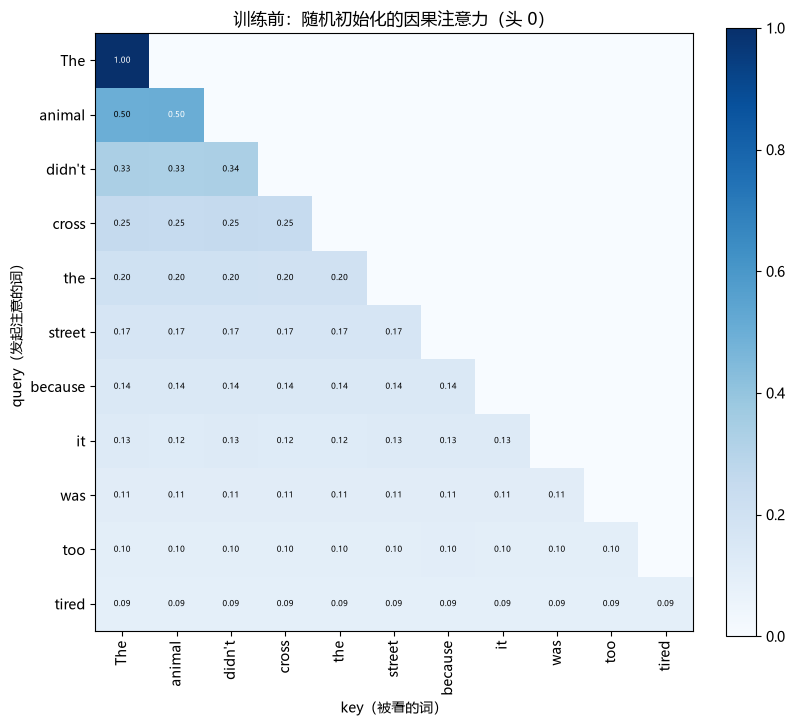

上半三角权重总和（应为 0）: 0.0


In [21]:
import matplotlib.pyplot as plt
import torch

# Windows 自带微软雅黑，解决中文与负号显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

def plot_attn(attn, tokens, title):
    '''注意力热力图：行 = query（谁在看），列 = key（看谁），颜色越深权重越大。'''
    n = len(tokens)
    fig, ax = plt.subplots(figsize=(n * 0.55 + 2, n * 0.55 + 2))
    im = ax.imshow(attn, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n), tokens, rotation=90)
    ax.set_yticks(range(n), tokens)
    ax.set_xlabel('key（被看的词）')
    ax.set_ylabel('query（发起注意的词）')
    ax.set_title(title)
    for i in range(n):                       # 格子里标出数字，方便对照
        for j in range(n):
            if attn[i, j] >= 0.05:
                ax.text(j, i, f'{attn[i, j]:.2f}', ha='center', va='center',
                        color='white' if attn[i, j] > 0.5 else 'black', fontsize=6)
    fig.colorbar(im, fraction=0.046)
    plt.tight_layout()
    plt.show()

# 例 1：训练前 —— 随机初始化，接近均匀地"回看过去"，且严格下三角
torch.manual_seed(8)
tokens = ['The', 'animal', "didn't", 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired']
X = torch.randn(1, len(tokens), 16)

dec = MultiHeadAttention(d_model=16, n_heads=4, causal=True)
_, attn = dec(X)
plot_attn(attn[0, 0].detach(), tokens, '训练前：随机初始化的因果注意力（头 0）')
print('上半三角权重总和（应为 0）:', attn[..., torch.triu(torch.ones(11, 11, dtype=torch.bool), 1)].sum().item())

### 9.2 训练后会长什么样？（示意）

随机参数没有语义。**经过训练**，注意力头会分化出各种"技能"：指代消解、语法依存、位置偏移……下面手工构造一个经典的**指代消解**形态——`it` 和 `tired` 都应强烈关注 `animal`（而不是 `street`）。这不是模型算出来的，而是"训练成功的某层某头"大致会长成的样子。

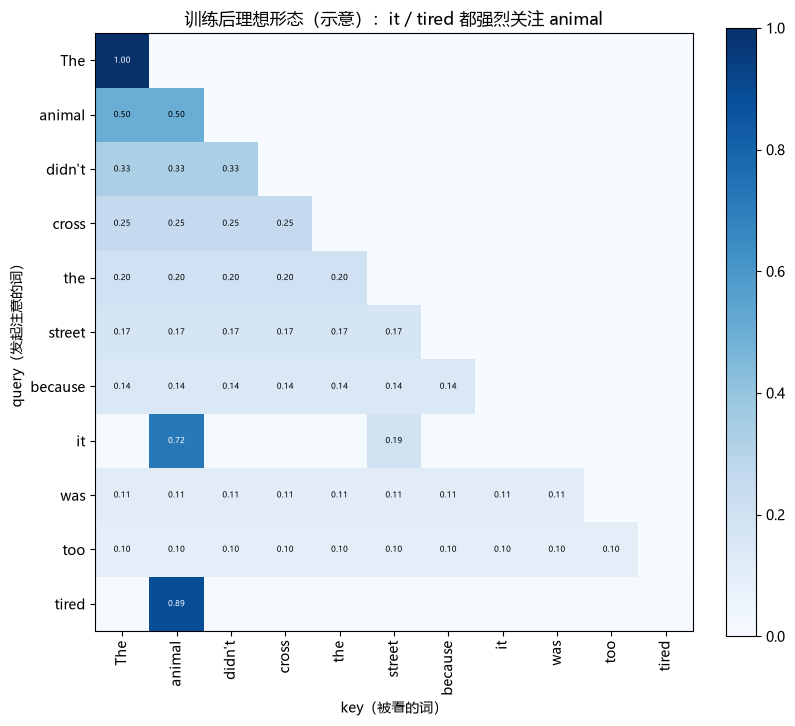

it → animal  的权重: 0.721
it → street 的权重: 0.191
tired → animal 的权重: 0.886


In [22]:
# 例 2：手工构造"训练后理想形态"——指代消解（The animal ... because it was too tired）
n = len(tokens)
A = torch.zeros(n, n)
for i in range(n):                    # 底色：因果均匀分布（第 i 行均分给 0..i）
    A[i, :i + 1] = 1.0 / (i + 1)

it, tired, animal, street = 7, 10, 1, 5
A[it] *= 0.1                          # 削弱 it 的均匀底色，再叠加语义偏好
A[it, animal] += 0.60                 # it → animal：强注意
A[it, street] += 0.15                 # street 只分到一点点
A[it] /= A[it].sum()

A[tired] *= 0.1
A[tired, animal] += 0.70              # tired 描述的也是 animal
A[tired] /= A[tired].sum()

plot_attn(A, tokens, '训练后理想形态（示意）：it / tired 都强烈关注 animal')
print(f'it → animal  的权重: {A[it, animal]:.3f}')
print(f'it → street 的权重: {A[it, street]:.3f}')
print(f'tired → animal 的权重: {A[tired, animal]:.3f}')

## 第 10 节 · Demo 2：训练一个 TinyGPT 学会"序列反转"

前面的组件拼起来就是一个 **decoder-only GPT**：

```
token 嵌入 + 位置嵌入  →  N 层 TransformerBlock(causal=True)  →  LayerNorm  →  输出头
```

我们给它一个最小任务：**输入 8 个数字，续写出它们的反转**。

### 任务构造：把"答案"拼在输入后面（teacher forcing）

```text
seq   = [3 1 4 1 5 9 2 6]                     # 随机数字序列，长 N=8
full  = [3 1 4 1 5 9 2 6 | 6 2 9 5 1 4 1]     # seq + flip(seq)[:-1]，长 2N-1
inp   = full[:-1]     # 长度 14：每个位置的输入
label = full[1:]      # 长度 14：右移一位，每个位置要预测的"下一个 token"
```

训练时不逐步生成，而是**一次并行**地让位置 k 预测 label[k]——这就是序列建模标准的
teacher forcing。因果掩码保证位置 k 只能看到 ≤k 的输入，所以"预测未来"没有作弊。

### 反转的关键：位置 k 必须"回头抄"位置 14−k

对输出位置 k∈[8,13]（反转段），label[k] = full[k+1] = seq[14−k]，而 seq[s] 就在位置 s。
所以模型想答对，注意力必须把权重集中到位置 **2N−2−k**：

```text
k       =  8   9  10  11  12  13
→ 14-k  =  6   5   4   3   2   1
```

训练完后我们会截获每一层每一头的注意力，看看是否真的出现了这种"回头抄"模式——
这就是可解释性研究里常说的 **induction head（归纳头）** 的雏形。

In [23]:
class TinyGPT(nn.Module):
    '''decoder-only 小模型：嵌入查表 + N 层 TransformerBlock(causal) + 输出头。
    依然只用 nn.Parameter / nn.Module 做参数管理，核心计算全是张量运算。'''
    def __init__(self, vocab_size: int, d_model: int = 64, n_heads: int = 4,
                 n_layers: int = 2, max_len: int = 32):
        super().__init__()
        self.W_tok = nn.Parameter(torch.randn(vocab_size, d_model) * 0.02)  # 词嵌入表
        self.W_pos = nn.Parameter(torch.randn(max_len, d_model) * 0.02)     # 位置嵌入表
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, causal=True)
                                     for _ in range(n_layers)])
        self.ln_f = LayerNorm(d_model)
        self.W_head = nn.Parameter(torch.randn(d_model, vocab_size) * 0.02) # 输出头

    def forward(self, idx):
        '''idx: (B, n) int64 token id → logits: (B, n, vocab)'''
        X = self.W_tok[idx] + self.W_pos[:idx.shape[1]]   # 两个查表结果相加（广播）
        for blk in self.blocks:
            X = blk(X)
        return self.ln_f(X) @ self.W_head

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int):
        '''贪心自回归：每步取最后位置的 logits 做 argmax，追加到序列尾。
        序列很短，直接全量重算；真实长序列需要 KV cache（见第 11 节思考题）。'''
        for _ in range(max_new_tokens):
            logits = self.forward(idx)
            idx = torch.cat([idx, logits[:, -1].argmax(-1, keepdim=True)], dim=1)
        return idx

VOCAB, D_MODEL, N_HEADS, N_LAYERS, N = 10, 64, 4, 2, 8

torch.manual_seed(0)
model = TinyGPT(VOCAB, D_MODEL, N_HEADS, N_LAYERS)
print(f'TinyGPT 参数量: {sum(p.numel() for p in model.parameters()):,}')

TinyGPT 参数量: 103,424


### 模型与训练

- **嵌入**：`W_tok[idx]` 查表（token id → 向量）+ `W_pos[:n]` 查表（位置 → 向量），直接相加——GPT-2 就是这种做法
- **主干**：2 层第 8 节的 `TransformerBlock(causal=True)`，零修改直接复用
- **输出头**：`ln_f(X) @ W_head` 把每个位置的向量映射为词表上的 logits
- **损失**：交叉熵。第 3 节我们手写过 softmax，这里直接用 `F.cross_entropy`
  （内部 = log_softmax + NLL），只是省点手写、训练更快

In [24]:
import torch.nn.functional as F

def make_batch(batch_size: int = 64):
    '''随机造一批"seq + 反转"数据，返回 (inp, label)，各长 2N-2=14。'''
    seq = torch.randint(0, VOCAB, (batch_size, N))
    full = torch.cat([seq, seq.flip(-1)[:, :-1]], dim=1)   # (B, 2N-1)
    return full[:, :-1], full[:, 1:]                        # 右移一位做标签

test_seq = torch.tensor([[3, 1, 4, 1, 5, 9, 2, 6]])
print('训练前 generate:', model.generate(test_seq, N - 1)[0].tolist())

opt = torch.optim.Adam(model.parameters(), lr=3e-4)
for step in range(1, 601):
    inp, label = make_batch()
    logits = model(inp)                                     # (B, 14, 10)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB), label.reshape(-1))
    opt.zero_grad()
    loss.backward()
    opt.step()
    if step == 1 or step % 100 == 0:
        print(f'step {step:4d} | loss {loss.item():.4f}')

# loss 停在 ≈1.16 不是没学好：位置 0..6 要预测随机序列的"下一个数字"，本质不可预测
# （最优 CE = ln10 ≈ 2.30）；7 个不可预测位置平摊到 14 个位置 → 理论下限 ≈ 7×2.30/14 ≈ 1.15，
# 实测已贴近下限，说明可学的部分（反转段）已学会。

gen = model.generate(test_seq, N - 1)[0].tolist()
gold = test_seq[0].tolist() + test_seq[0].flip(0)[:-1].tolist()
print('\n输入           :', test_seq[0].tolist())
print('训练后 generate:', gen)
print('正确答案 full  :', gold)
print('生成 == 答案?   ', gen == gold)

训练前 generate: [3, 1, 4, 1, 5, 9, 2, 6, 6, 6, 6, 6, 6, 3, 2]
step    1 | loss 2.3115
step  100 | loss 1.6434
step  200 | loss 1.2240
step  300 | loss 1.1867
step  400 | loss 1.1742
step  500 | loss 1.1638
step  600 | loss 1.1630

输入           : [3, 1, 4, 1, 5, 9, 2, 6]
训练后 generate: [3, 1, 4, 1, 5, 9, 2, 6, 6, 2, 9, 5, 1, 4, 1]
正确答案 full  : [3, 1, 4, 1, 5, 9, 2, 6, 6, 2, 9, 5, 1, 4, 1]
生成 == 答案?    True


输出位置 k : [8, 9, 10, 11, 12, 13] （这些位置要输出反转后的数字）
理想源位置: [6, 5, 4, 3, 2, 1] （注意力应集中在这里）

layer 0: h0 100% | h1 100% | h2 100% | h3 100%
layer 1: h0 67% | h1 67% | h2 67% | h3 67%

最佳头：layer 0 · head 0，吻合率 100%


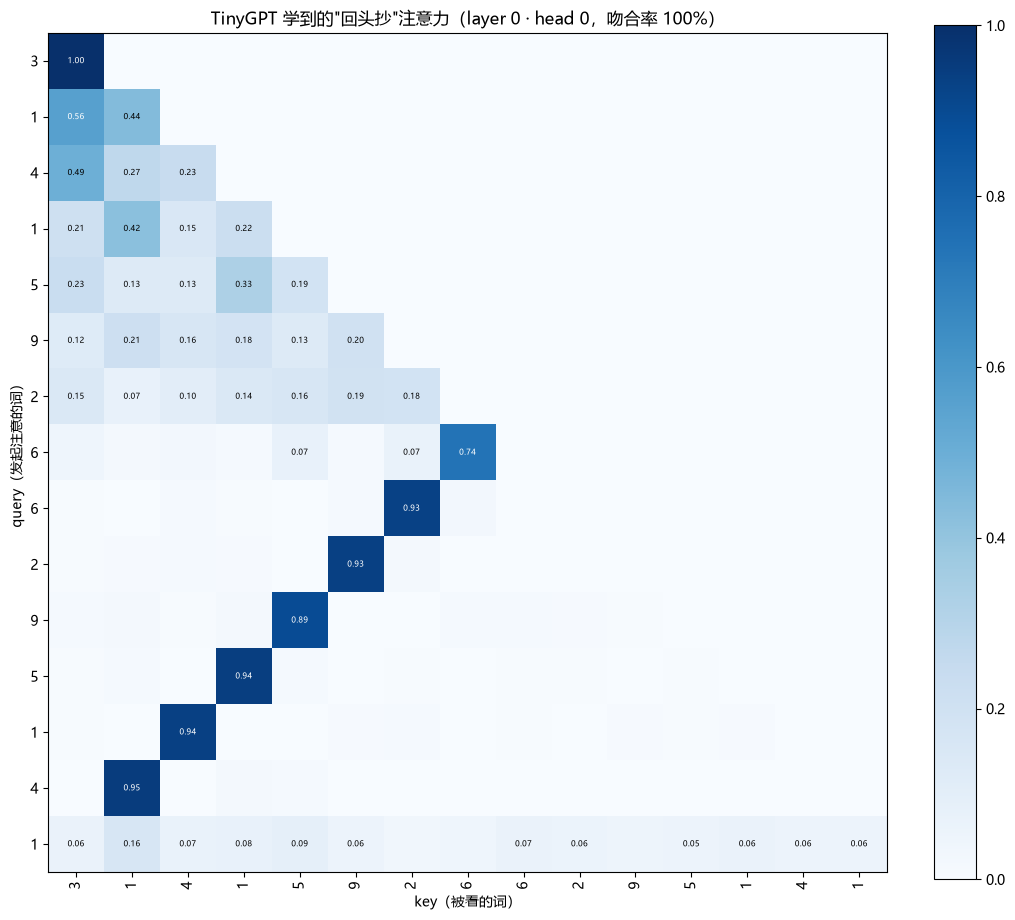

In [25]:
# ---- 截获每层注意力：TransformerBlock.forward 只返回 X，
#      所以手动复现 forward（与第 8 节实现逐行一致），在 attn 处截获权重 ----
idx = model.generate(test_seq, N - 1)                    # (1, 15) 完整序列
tokens_full = [str(int(t)) for t in idx[0]]              # 15 个 token 字符串

X = model.W_tok[idx] + model.W_pos[:idx.shape[1]]
attn_maps = []                                           # 每层一个 (n_heads, n, n)
with torch.no_grad():
    for blk in model.blocks:
        out, A = blk.attn(blk.ln1(X))                    # ← forward 的注意力半步
        X = X + out
        X = X + blk.ffn(blk.ln2(X))                      # ← forward 的 FFN 半步
        attn_maps.append(A[0])                           # 去掉 batch 维 → (h, n, n)

# ---- "回头抄"吻合率：输出位置 k∈[8,13] 的注意力 argmax 是否 = 14-k ----
ks = torch.arange(N, 2 * N - 2)                          # [8..13]（位置 14 不在训练分布内）
ideal = 2 * N - 2 - ks                                   # [6, 5, 4, 3, 2, 1]
print('输出位置 k :', ks.tolist(), '（这些位置要输出反转后的数字）')
print('理想源位置:', ideal.tolist(), '（注意力应集中在这里）\n')

best = (0.0, 0, 0)
for li, A in enumerate(attn_maps):
    row = []
    for hi in range(A.shape[0]):
        hits = (A[hi][ks].argmax(-1) == ideal).float().mean().item()
        row.append(f'h{hi} {hits:.0%}')
        if hits > best[0]:
            best = (hits, li, hi)
    print(f'layer {li}: ' + ' | '.join(row))

hits, li, hi = best
print(f'\n最佳头：layer {li} · head {hi}，吻合率 {hits:.0%}')
plot_attn(attn_maps[li][hi], tokens_full,
          f'TinyGPT 学到的"回头抄"注意力（layer {li} · head {hi}，吻合率 {hits:.0%}）')

## 第 11 节 · 总结与思考题

### 我们从零手写了什么

| 组件 | 公式 / 做法 | 手写模块 | 数值验证 |
|---|---|---|---|
| softmax 注意力 | softmax(QKᵀ/√d_k)·V | 第 3~4 节逐步拆解 | vs `torch.softmax` 偏差 4e-9 |
| √d_k 缩放 | Var(q·k) = d_k，除掉防饱和 | 第 4 节实验 | 平均熵 0.17 → 4.12 |
| 自注意力 | W_q / W_k / W_v 可学习投影 | `SelfAttention`（第 5 节） | 梯度正常回传 |
| 多头注意力 | 大矩阵拆头 + `W_o` 拼回 | `MultiHeadAttention`（第 6 节） | 单头拼接对照偏差 **0.0** |
| 因果掩码 | softmax 前 `masked_fill(-inf)` | `causal_mask`（第 7 节） | 未来位置权重和 **0.0** |
| Transformer Block | Pre-LN 残差 + 4×FFN(GELU) | `TransformerBlock`（第 8 节） | vs 官方实现偏差 **1.2e-7** |
| 完整 GPT | 嵌入 + N 层 Block + 输出头 | `TinyGPT`（第 10 节） | 序列反转 100% 正确 |

### 核心要点

1. 注意力 = **可微分的软字典查询**：query 与所有 key 算相似度 → softmax 归一化 → 加权求和 value
2. 全程只有矩阵乘法 + 一次 softmax，序列内完全并行（RNN 的逐步依赖消失了）
3. 多头 = 多个子空间并行做注意力，参数量与"一个更大的单头"基本相同
4. 因果掩码只是一个上三角 bool 矩阵，在 softmax 之前把未来位置填 −inf
5. Pre-LN + 残差 + 4 倍 FFN，这个三件套让几十层堆叠也训练得动
6. 整个 GPT 没有魔法：**查表 + 手写注意力 + 残差 + LayerNorm + MLP**，你已经全部写过了

### 思考题（先想 30 秒，再看提示）

1. **位置编码为什么必要？** 把 `W_pos` 删掉再训练第 10 节的任务，会发生什么？
   *提示：没有位置编码的注意力对输入顺序"置换等变"——打乱输入，输出跟着打乱，
   模型感知不到顺序；而反转任务恰恰必须靠"位置"才能定位要抄的数字。*
2. **KV cache 为什么能加速生成？** 我们的 `generate` 每步全量重算，浪费在哪？
   哪些中间张量在生成新 token 时其实根本不变？
3. **cross-attention 怎么改？** 翻译模型中 Q 来自解码器、K/V 来自编码器。
   我们的 `MultiHeadAttention` 需要改哪几行？（提示：让 K/V 用另一份输入即可）
4. **GQA / MQA 是省什么？** 推理显存瓶颈常在 KV cache。让多个 query 头共享同一组
   K/V 头，省在哪、代价是什么？
5. **注意力是"内容寻址"，那"位置寻址"呢？** 第 10 节的头其实是按 *位置* 抄的——
   想想是什么机制让 `W_q/W_k` 能从 token 内容中"读出位置"。

### 延伸阅读

- Vaswani et al., 2017, *Attention Is All You Need* —— 一切的开端
- Jay Alammar, *The Illustrated Transformer* —— 最经典的图解
- Anthropic, *A Mathematical Framework for Transformer Circuits* 与
  *In-context Learning and Induction Heads* —— 第 10 节"回头抄"现象的严格版本
- Karpathy 的 minGPT / nanoGPT —— 与本文手写结构几乎同构的生产级最小实现，
  读完这个 notebook 就能直接读懂